## Assignment 1 - Mobility Modelling (LTAT.06.016)

This is the first assignment in the course Mobility Modelling. It is based on **Tutorials 1-2** and it's main aim is to get acquainted with various tools used in spatial analysis and to start working with movement trajectories. During this assignment, you will get acquainted with libraries such as `geopandas`, `shapely`, `movingpandas` etc.

* All the tasks that require some action are highlighted in **<span style="color:#394d9e">dark blue</span>**.
* Please do not edit the code provided (that includes variable names) unless you have a good reason for it, in which case indicate clearly what you have changed.
* Feel free to create as many new cells as you need for each task.

#### Library imports

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import pyproj
import matplotlib.pyplot as plt
import movingpandas as mpd
import contextily as ctx
from shapely import from_wkt
from datetime import datetime, timedelta

### Exercise 1 - Reading and understanding the data (2p)

In mobility modelling, we mostly work with movement data - that usually means GPS locations or trajectories as linestrings. In this assignment we will use a small dataset from Tartu Smart Bike that includes the GPS points from one day, 15th of March 2021. This still includes a good amount of trips, but the data doesn't get unmanagable - since a single trajectory is made up of many points, these datasets can quickly get very large and slow to process.

Before we can actually learn something from the data, we need to make sure it's in a format we can understand. In our case, we use GeoPandas dataframes to store our data, so the first step is converting our raw data to a GeoDataFrame. It is also a good habit to take a quick look at your data before any deeper analysis to make sure everything is as expected.

**<span style="color:#394d9e">Start by importing the attached dataset from *data/tartu_smart_bike_march_15_2021.csv* using pandas and display the first five rows of the dataset.</span>**

In [2]:
### Importing and displaying the data ###

gps_points = pd.read_csv("data/tartu_smart_bike_march_15_2021.csv")
gps_points.head()

,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.767471666666665 58.369943333333325)
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729333333333 58.36988166666666)
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726333333333 58.36978166666666)
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.767368333333334 58.36965)
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.767475 58.369515)


As we also encountered in assignment0, for now `gps_points` is a regular dataframe and values in geometry column are just strings. We want to transform it into a GeoDataFrame, so we need to transform the strings to Shapely points. There are two easy options - either by using Shapely's `from_wkt()` method or creating Shapely Points from latitude and longitude columns.

**<span style="color:#394d9e">Use either of the methods to create geometry objects and convert the data into a GeoDataFrame.</span>**

In [3]:
### Creating geometry type objects ###
### Creating geometry type objects ###

gps_points["geometry"] = gps_points["geometry"].apply(from_wkt)

##districts["geometry"] = districts["geometry"].apply(from_wkt)


In [4]:
### Converting gps_points to a GeoDataFrame ###
gps_points = gpd.GeoDataFrame(gps_points)
gps_points
##gdf_districts = gpd.GeoDataFrame(districts)
##gdf_districts


,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.76747 58.36994)
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729 58.36988)
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726 58.36978)
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.76737 58.36965)
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.76748 58.36951)
...,...,...,...,...,...,...,...,...,...
23859,286110,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.350850,26.726895,2021-03-15,23:59,POINT (26.72689 58.35085)
23860,286111,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351022,26.726885,2021-03-15,23:59,POINT (26.72688 58.35102)
23861,286112,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351190,26.726880,2021-03-15,23:59,POINT (26.72688 58.35119)
23862,286113,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351353,26.726863,2021-03-15,23:59,POINT (26.72686 58.35135)


You can make sure that this worked by plotting the dataset. This should create a rough map of the points (and not a histogram or a lineplot).

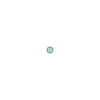

In [5]:
gps_points.loc[1]["geometry"]

<Axes: >

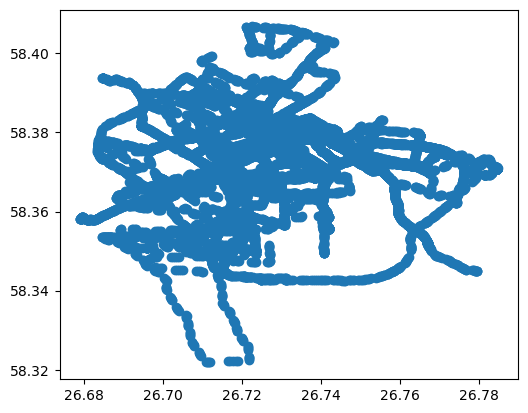

In [6]:
gps_points.plot()

As mentioned above, it is a good idea to check out your dataset before further analysis. In addition to just plotting your data, Pandas (and thus GeoPandas) provides some very nice built-in methods for exploring your dataset. One of them is `.info()`, which tells you the type and amount of non-null values in each column, which is very useful for finding entries with missing values. A second useful method when it comes to numeric data is `.describe()`, which gives you an overview of the numeric columns in your dataset (min, max and mean values of each column among others). For this particular dataset it's not that helpful, but it can be very handy when looking at distances or durations of trips for example.

**<span style="color:#394d9e">Use .info() and .describe() methods on the dataset and explore what kind of information is provided.</span>**

In [7]:
### Use .info() method on the dataset ###

gps_points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23864 entries, 0 to 23863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Unnamed: 0   23864 non-null  int64   
 1   route_code   23864 non-null  int64   
 2   userID       23864 non-null  object  
 3   cyclenumber  23864 non-null  int64   
 4   latitude     23864 non-null  float64 
 5   longitude    23864 non-null  float64 
 6   coord_date   23864 non-null  object  
 7   coord_time   23864 non-null  object  
 8   geometry     23864 non-null  geometry
dtypes: float64(2), geometry(1), int64(3), object(3)
memory usage: 1.6+ MB


In [8]:
### Use .describe() method on the dataset ###

gps_points.describe()

,Unnamed: 0,route_code,cyclenumber,latitude,longitude
count,23864.000000,2.386400e+04,23864.000000,23864.000000,23864.000000
mean,273154.001634,1.615814e+12,2672.447368,58.372915,26.727542
std,6903.472985,1.309548e+07,76.302743,0.010918,0.020243
min,261207.000000,1.615777e+12,2544.000000,58.321842,26.679148
25%,267180.750000,1.615807e+12,2611.000000,58.367071,26.715035
50%,273150.500000,1.615816e+12,2665.000000,58.374276,26.725912
75%,279118.250000,1.615824e+12,2743.000000,58.379237,26.739799
max,286114.000000,1.615842e+12,2795.000000,58.406810,26.784635


### Exercise 2 - Understanding CRS (2p)

Map projections tackle the problem of portraying the surface of the earth (which is spherical) on a flat piece of paper or a computer screen. A coordinate reference system (CRS) defines how the two-dimensional map in your GIS is related to real places on the earth. The decision as to which map projection and coordinate reference system to use, depends on the regional extent of the area you want to work in, on the analysis you want to do and often on the availability of data. You can find out more about CRS [here](https://docs.qgis.org/3.22/en/docs/gentle_gis_introduction/coordinate_reference_systems.html). For now, it's important to understand when different CRS can come in handy. Here are three which we might need to use:

In [9]:
crs_gps = pyproj.CRS.from_epsg('4326') # WGS84 Mercator (degrees)
crs_web = pyproj.CRS.from_epsg('3857') # Pseudo-Mercator (meters)
crs_est = pyproj.CRS.from_epsg('3301') # Estonian Coordinate System

Right now, both of our datasets use EPSG:4326 system. While it's nice and simple, it's not great for visualizing the data nor will it provide accurate calculations in terms of area and distances, as it uses degrees. To help you better understand and visualize the data, [`contextily`](https://contextily.readthedocs.io/en/latest/index.html) might come in handy!

In [10]:
# While looking at the data, we can tell that the CRS is EPSG:4326,
# but our GeoDataFrame doesn't know this, if we haven't specified it when creating it.
# Thus, we need to assign the CRS to manually
gps_points = gps_points.set_crs(crs_gps)

C:\Users\sonia\micromamba\envs\geopython2023\lib\site-packages\contextily\tile.py:581: UserWarning: The inferred zoom level of 30 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


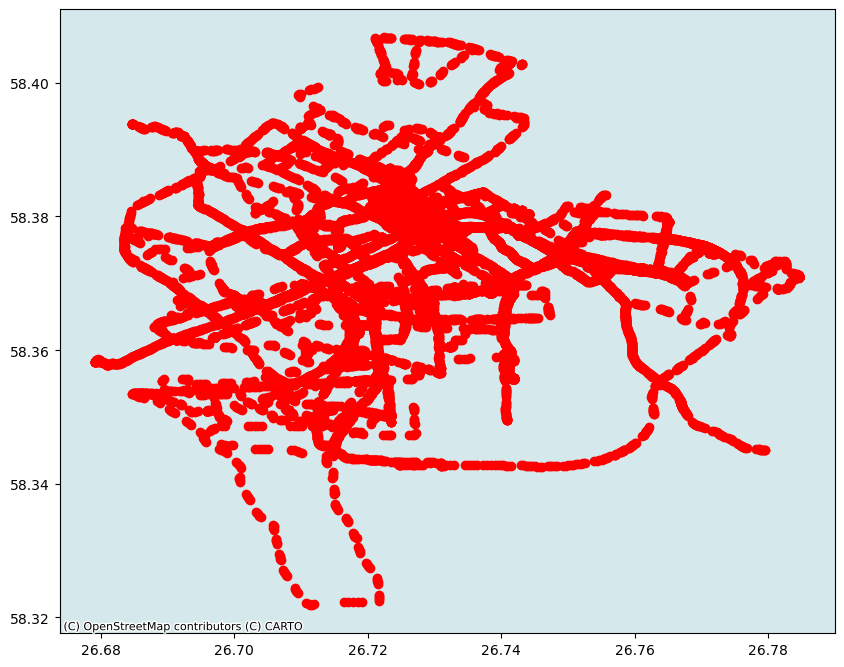

In [11]:
fig,ax = plt.subplots(1,1, figsize=(10,10))
gps_points.plot(ax=ax, color="red")
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)

Contextily provides different tile maps from the internet to help you create better visualizations or get a better understanding of the data. The style of different tile providers vary a lot and you can check out some of them [here](https://contextily.readthedocs.io/en/latest/providers_deepdive.html). But right now there's an issue - `contextily` as most web apps require the EPSG:3857 metric projection and right now we have drawn our network in the middle of the ocean.

**<span style="color:#394d9e">Change the CRS of our dataset and to plot it again.</span>**

In [12]:
gps_points = gps_points.to_crs(crs_web)

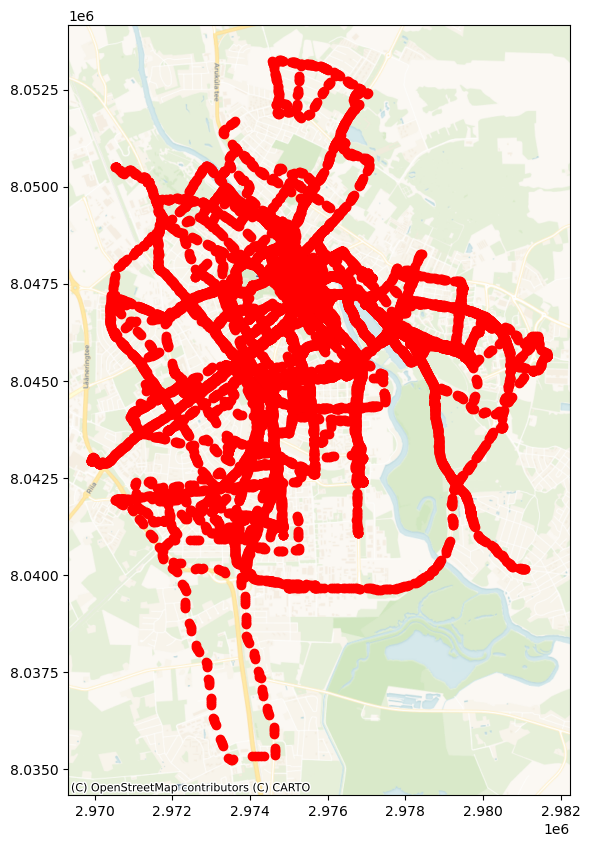

In [13]:
### Change the CRS and plot the data ###

fig,ax = plt.subplots(1,1, figsize=(10,10))
gps_points.plot(ax=ax, color="red")
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)

That's much better!

**NB!** While EPSG:3857 is a metric projection, it's still not perfect for calculating distances, as it uses WGS84 latitude and logitude as if they were angles on a sphere, leading to distortions especially when you move away from the equator. In these situations, it's better to use a local CRS. In our case that would be EPSG:3301 - Estonian Coordinate System. Later when working with lines or polygons, make sure your data is in the correct CRS before calculating distance or area.

**<span style="color:#394d9e">To illustrate that, use Shapely .distance() method to find the distance between the first and the last point in the dataset before and after changing it to appropriate CRS.</span>**

In [14]:
### Calculate the distance between the first and last point of the dataset without changing CRS ###
distance = (gps_points.geometry.iloc[0].distance(gps_points.geometry.iloc[-1]))/1000
print("Distance between the first and last point in km:", distance)

Distance between the first and last point in km: 5.980541288465328


In [15]:
### Change the CRS to an appropriate one and calculate the distance between the first and last point of the dataset again ###

gps_points = gps_points.to_crs(crs_est)
#calculating distance in estonian coordinate system
distance = (gps_points.geometry.iloc[0].distance(gps_points.geometry.iloc[-1]))/1000
print("Distance between the first and last point in km:", distance)

Distance between the first and last point in km: 3.142191655298766


In [16]:
# Let's change the CRS back to the original one
gps_points = gps_points.to_crs(crs_gps)

The distance between the points should be around 3.14 km.

### Exercise 3 - From points to trajectories (3p)

There are multiple ways to analyze movement trajectories. One option would be to collect the points with the same route ID and create Shapely LineStrings from them. But there are also libraries that make working with trajectories easier and include various useful built-in methos - such a library is `movingpandas`. As `movingpandas` relies on timestamps to sort the points within a trajectory, we need to make sure, that there is a proper time value in our dataset.

**<span style="color:#394d9e">Use coord_date and coord_time features to create a time column.</span>**

In [17]:
### Create a time column with datetime values ###
##exercise 3
### Create a time column with datetime values ###
gps_points['time'] = pd.to_datetime(gps_points['coord_date'] + ' ' + gps_points['coord_time'])
gps_points

,Unnamed: 0,route_code,userID,cyclenumber,latitude,longitude,coord_date,coord_time,geometry,time
0,261207,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369943,26.767472,2021-03-15,06:01,POINT (26.76747 58.36994),2021-03-15 06:01:00
1,261208,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369882,26.767293,2021-03-15,06:01,POINT (26.76729 58.36988),2021-03-15 06:01:00
2,261209,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369782,26.767263,2021-03-15,06:01,POINT (26.76726 58.36978),2021-03-15 06:01:00
3,261210,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369650,26.767368,2021-03-15,06:01,POINT (26.76737 58.36965),2021-03-15 06:01:00
4,261211,1615777240950,df060d69-7452-4748-bf64-1aec19af60b7,2635,58.369515,26.767475,2021-03-15,06:01,POINT (26.76747 58.36951),2021-03-15 06:01:00
...,...,...,...,...,...,...,...,...,...,...
23859,286110,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.350850,26.726895,2021-03-15,23:59,POINT (26.72689 58.35085),2021-03-15 23:59:00
23860,286111,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351022,26.726885,2021-03-15,23:59,POINT (26.72688 58.35102),2021-03-15 23:59:00
23861,286112,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351190,26.726880,2021-03-15,23:59,POINT (26.72688 58.35119),2021-03-15 23:59:00
23862,286113,1615841503063,2ef90b1b-b78a-441f-82b7-8bfb21bdc8f6,2730,58.351353,26.726863,2021-03-15,23:59,POINT (26.72686 58.35135),2021-03-15 23:59:00


In [18]:
# MovingPandas needs the time to be the index column
gps_points = gps_points.set_index("time")

**<span style="color:#394d9e">Now we should be able to convert the points into a movingpandas TrajectoryCollection.</span>**

In [19]:
### Create a collection of trajectories based on the GPS points ###
minimum_length = 100
collection = mpd.TrajectoryCollection(gps_points, 'route_code', min_length=minimum_length)


**<span style="color:#394d9e">Plot the collection to be sure.</span>**

<Axes: >

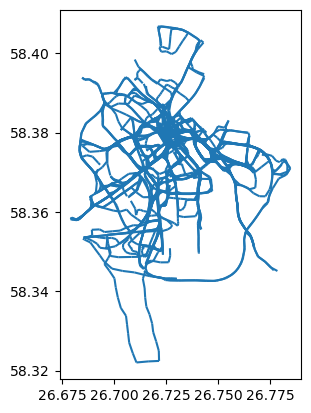

In [20]:
### Plot the collection ###

collection.plot()


In [21]:
print(collection)

TrajectoryCollection with 316 trajectories


**<span style="color:#394d9e">Answer the question - how many trajectories make up our collection?</span>**

In [22]:
### Answer the question ###

collection

TrajectoryCollection with 316 trajectories

### Exercise 3 - Exploring trajectories (5p)

The `movingpandas` Trajectory class has a lot of useful methods already built in for understanding the course of the trajectory - for example, you can look up the duration and length of the trajectory or you can explore the speed throughout a trajectory. We will now use the methods from Trajectory class (see [documentation](https://movingpandas.readthedocs.io/en/main/trajectory.html)) to complete various tasks. There's an example trajectory provided for you.

In [23]:
example_trajectory = collection.trajectories[272]

**<span style="color:#394d9e">What is the duration of the example trajectory?</span>**

In [24]:
### Trajectory duration ###

example_trajectory.get_duration()

datetime.timedelta(seconds=2760)

**<span style="color:#394d9e">What is the length of the example trajectory?</span>**

In [25]:
### Trajectory length ###

example_trajectory.get_length()

8966.320482837787

**<span style="color:#394d9e">Plot the example trajectory.</span>**

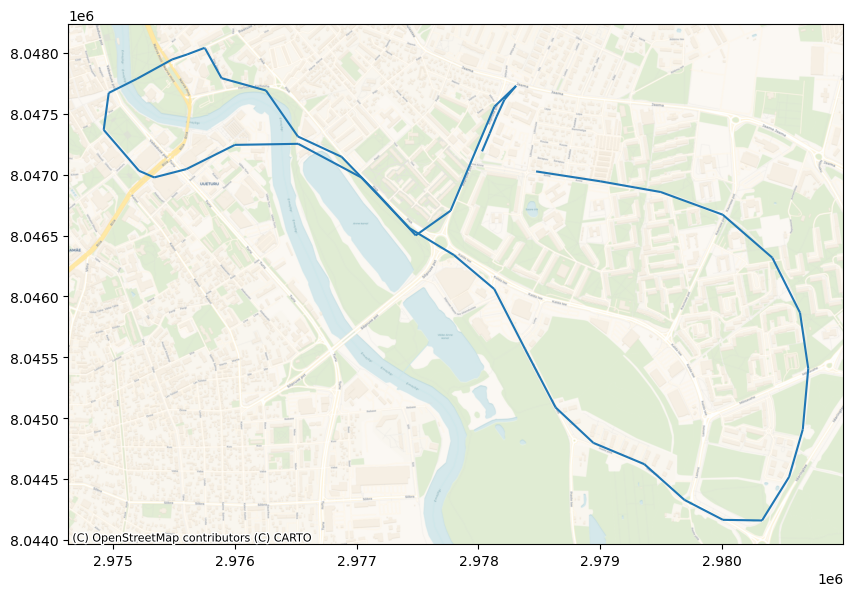

In [26]:
### Plot the trajectory ###
# You can use the built-in interactive plot, but this might require installing additional libraries and might be more tricky
# Alternatively, you could use regular plotting with Contextily as in previous assignment to provide a basemap

fig, ax = plt.subplots(figsize=(10, 10))
example_trajectory.to_crs(crs_web).plot(ax=ax)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)

Do you notice anything strange about the trajectory? It seems that our cyclist has been "cutting corners" quite a lot, sometimes even going through water. The reason for that is the underlying data is not dense enough - there are some gaps in the GPS data and thus time and distance between some points is large enough to create such distortions. When working with GPS data, it is often best to map the trajectories to the underlying road network (assuming our users prefer to move on roads). The task of matching the recorded points to a representation of a road network is called **map-matching** and is very tricky and diverse in itself, so we are not going to try that in this assignment.

**<span style="color:#394d9e">Next, add speed to the trajectory, make sure it's in km/h.</span>**

In [27]:
### Add speed to the trajectory ###

example_trajectory.add_speed(overwrite=True, units=("km", "h"))

**<span style="color:#394d9e">Plot the trajectory again, but now use speed column for color coding.</span>**

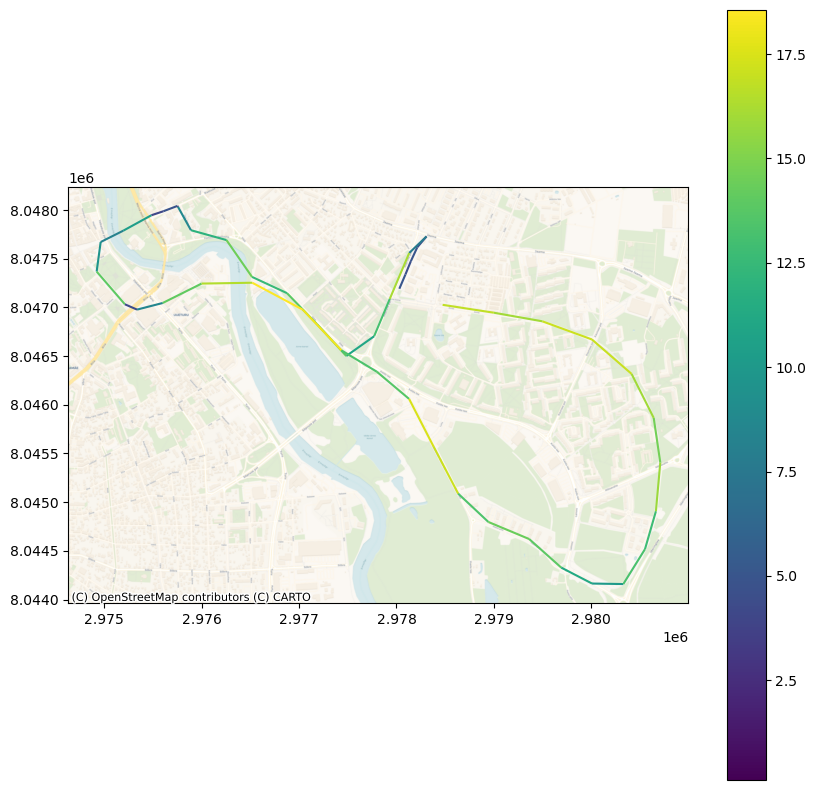

In [28]:
### Plot the trajectory using speed attribute ###

fig, ax = plt.subplots(figsize=(10, 10))
example_trajectory.to_crs(crs_web).plot(ax=ax, column="speed", legend=True)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)

### Exercise 4 - Aggregating trajectories (3p)

Very often, instead of looking at individual trajectories, we'd rather want to see the "big picture". For that we need to aggregate the trajectories and `movingpandas` can help us do just that. This could help us identify the most busy areas in the city or explore the flow of cyclists between different districts. 

**<span style="color:#394d9e">Aggregate the trajectories into clusters - experiment with different min_distance, max_distance and min_stop_duration values, to find a clustering that is most informative in your opinion.</span>**

In [29]:
### Aggregating the trajectories ###
agg = mpd.TrajectoryCollectionAggregator(collection, min_distance=500, max_distance=2000, min_stop_duration=timedelta(minutes=10))

flows = agg.get_flows_gdf()
clusters = agg.get_clusters_gdf()

**<span style="color:#394d9e">Plot the resulting clusters and flows using proportional symbols.</span>**

In [30]:
flows

,geometry,weight
0,"LINESTRING (26.77242 58.37174, 26.75847 58.37385)",16
1,"LINESTRING (26.75847 58.37385, 26.76731 58.35014)",3
2,"LINESTRING (26.71032 58.37248, 26.69241 58.37121)",13
3,"LINESTRING (26.69241 58.37121, 26.71032 58.37248)",27
4,"LINESTRING (26.71032 58.37248, 26.72648 58.37918)",39
5,"LINESTRING (26.74055 58.37680, 26.72648 58.37918)",43
6,"LINESTRING (26.72648 58.37918, 26.71032 58.37248)",19
7,"LINESTRING (26.72648 58.37918, 26.74055 58.37680)",54
8,"LINESTRING (26.74055 58.37680, 26.73761 58.36564)",12
9,"LINESTRING (26.73761 58.36564, 26.74743 58.34505)",1


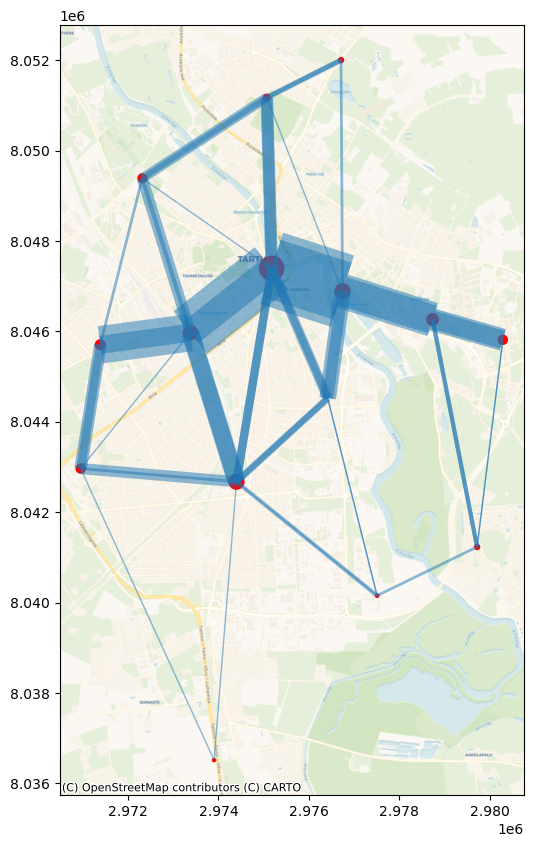

In [31]:
### Plotting the results ###
# Similarly to the previous task, you can either use the built-in interactive plot or plot the clusters and flows using regular plot + Contextily

fig, ax = plt.subplots(figsize=(10, 10))
clusters.to_crs(crs_web).plot(ax=ax, markersize=clusters["n"], color="red")
flows.to_crs(crs_web).plot(ax=ax, lw=flows["weight"], alpha=0.5)
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Voyager)
plt.savefig('example_plot.png')

<hr>

#### Feedback

This is the end of the tasks. Feel free to leave any comments regarding the tasks.

**How long did it take for you to finish these tasks? What was the toughest part?**